In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
cmap = plt.cm.get_cmap('coolwarm')  # 使用coolwarm colormap

from scipy.signal import find_peaks

/tmp/ipykernel_2582165/1828140098.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')  # 使用coolwarm colormap


In [2]:
def snr(data):
    return np.mean(data[1]) / np.std(data[1])
def read(path):
    with open(path, 'r', encoding='ISO-8859-1') as f:
        lines = f.readlines()
    data = np.vstack([[float(i.split('\t')[0]), float(i.split('\t')[1].replace('\n', ''))] 
                  for i in lines if not i.startswith('#')]).T
    data[1] = data[1]/data[1].max()
    return data, find_peaks(data[1], prominence=0.1)
def plot(data, kwargs={}):
    # plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.plot(data['spectrum'][0], data['spectrum'][1], label=f'{data['dir'].split('.')[0]}:{data['snr']:.4f}', c=cmap(data['color']))
    plt.xlabel('Raman Shift')
    plt.legend(title='SNR')
def plot_batch(dir):
    dirlist = os.listdir(dir) 
    df = pd.DataFrame(
        {
            'dir': dirlist,
            'spectrum': [read(os.path.join(dir, i))[0] for i in dirlist],
            'peaks': [read(os.path.join(dir, i))[1] for i in dirlist]
        }
    )
    df['snr'] = df['spectrum'].apply(snr)
    df = df.sort_values(by='snr')
    df['color'] = [i/df['snr'].values.max() for i in df['snr'].values]
    for i, data in df.iterrows():
        plot(data)
    

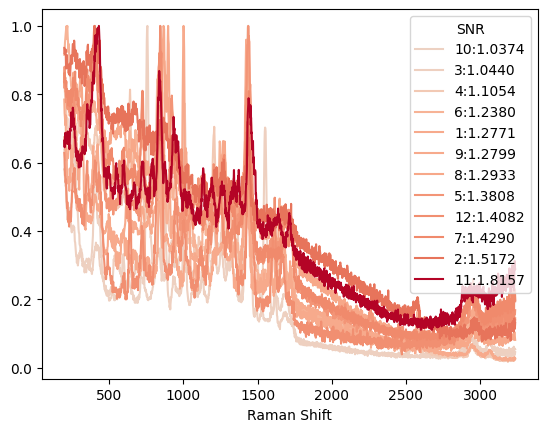

In [3]:
plot_batch('data/peptide data-532and785 - for share/785')

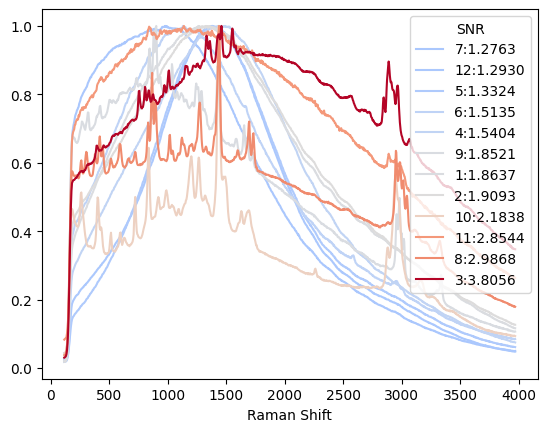

In [4]:
plot_batch('data/peptide data-532and785 - for share/532')

In [5]:
import requests
import numpy as np
from typing import List, Dict, Union

class SpectrometerController:
    def __init__(self, base_url: str, timeout: int = 30):
        """
        初始化光谱仪控制器
        
        Args:
            base_url: 仪器的基础URL，例如 "http://192.168.1.100:8080"
            timeout: 请求超时时间（秒）
        """
        self.base_url = base_url.rstrip('/')
        self.timeout = timeout
        self.scan_endpoint = f"{self.base_url}/api/scan"  # 根据实际接口调整
    
    def scan(self, wavenumber: float, power: float) -> np.ndarray:
        """
        向仪器发送扫描指令并返回光谱数据
        
        Args:
            wavenumber: 激发波数 (cm^-1) 或波长 (nm)
            power: 激光功率 (mW 或 %)
            
        Returns:
            采集到的光谱数据 (numpy数组)
        """
        # 构建JSON格式的条件参数
        condition = {
            "wavenumber": float(wavenumber),
            "power": float(power),
            # 可选：添加其他控制参数
            "integration_time": 1000,  # 积分时间(ms)
            "average": 3               # 平均次数
        }
        
        try:
            # 发送HTTP POST请求，JSON格式
            response = requests.post(
                url=self.scan_endpoint,
                json=condition,           # 自动设置 Content-Type: application/json
                timeout=self.timeout,
                headers={
                    "Accept": "application/json",
                    # 如需认证，添加："Authorization": "Bearer YOUR_TOKEN"
                }
            )
            
            # 检查响应状态
            response.raise_for_status()
            
            # 解析返回的JSON数据
            data = response.json()
            
            # 假设仪器返回格式：{"spectrum": [....], "status": "success", "metadata": {...}}
            if data.get("status") != "success":
                raise RuntimeError(f"仪器返回错误: {data.get('error', 'Unknown error')}")
            
            # 转换为numpy数组
            spectrum = np.array(data["spectrum"])
            return spectrum
            
        except requests.exceptions.ConnectionError:
            raise ConnectionError(f"无法连接到仪器: {self.base_url}")
        except requests.exceptions.Timeout:
            raise TimeoutError("仪器响应超时")
        except requests.exceptions.JSONDecodeError:
            raise ValueError("仪器返回非JSON格式数据")
    
    def batch_scan(self, wavenumber_list: List[float], 
                   power_list: List[float]) -> List[np.ndarray]:
        """
        批量扫描：遍历所有波长和功率组合
        
        Returns:
            光谱列表，索引顺序: [w1_p1, w1_p2, ..., w2_p1, w2_p2, ...]
        """
        spectrum_list = []
        total = len(wavenumber_list) * len(power_list)
        count = 0
        
        print(f"开始批量扫描，共 {total} 个条件组合...")
        
        for wavenumber in wavenumber_list:
            for power in power_list:
                count += 1
                print(f"[{count}/{total}] 波数: {wavenumber}, 功率: {power}")
                
                try:
                    spectrum = self.scan(wavenumber, power)
                    spectrum_list.append(spectrum)
                except Exception as e:
                    print(f"  ⚠️  采集失败: {e}")
                    # 可选：填充NaN或跳过
                    spectrum_list.append(np.full(1024, np.nan))  # 假设光谱长度为1024
        
        return spectrum_list


def calculate_snr(spectrum_list: List[np.ndarray], 
                  signal_region: slice = slice(400, 600),
                  noise_region: slice = slice(0, 100)) -> np.ndarray:
    """
    计算信噪比
    
    Args:
        spectrum_list: 光谱列表
        signal_region: 信号区域切片（默认中间部分）
        noise_region: 噪声区域切片（默认边缘部分）
    
    Returns:
        每个光谱的SNR数组
    """
    snr_values = []
    
    for spectrum in spectrum_list:
        if np.all(np.isnan(spectrum)):
            snr_values.append(0.0)
            continue
            
        # signal = np.mean(spectrum[signal_region])
        # noise = np.std(spectrum[noise_region])
        
        # # 避免除零
        # snr_val = signal / noise if noise != 0 else 0
        snr_values.append(np.mean(spectrum) / np.std(spectrum))
    
    return np.array(snr_values)


def find_optimal_conditions(snr_list: np.ndarray, 
                           wavenumber_list: List[float],
                           power_list: List[float]) -> Dict:
    """
    找到信噪比最大的条件
    
    Returns:
        最优条件字典
    """
    max_idx = np.argmax(snr_list)
    
    # 将一维索引转换为二维坐标
    n_power = len(power_list)
    w_idx = max_idx // n_power
    p_idx = max_idx % n_power
    
    return {
        "max_snr": float(snr_list[max_idx]),
        "optimal_wavenumber": wavenumber_list[w_idx],
        "optimal_power": power_list[p_idx],
        "index": max_idx
    }


# ==================== 使用示例 ====================

if __name__ == "__main__":
    
    # 1. 初始化控制器（替换为实际仪器IP）
    controller = SpectrometerController(base_url="http://192.168.1.50:8080")
    
    '''2. 定义扫描参数
    有哪些，范围是什么'''
         
    wavenumber_list = [532, 633, 785]  # 波数范围 (cm^-1)
    power_list = []               # 功率范围 (mW)
                                  # 曝光时间 
                                # ced中心波长
                                # sid
    '''# 3. 批量采集
    仪器的响应有哪些'''
    spectrum_list = controller.batch_scan(wavenumber_list, power_list)
    
    # 4. 计算信噪比
    snr_list = calculate_snr(spectrum_list) #波长还是位移
    
    # 5. 找到最优条件
    result = find_optimal_conditions(snr_list, wavenumber_list, power_list)
    
    print("\n" + "="*40)
    print("最优条件:")
    print(f"  波数: {result['optimal_wavenumber']} cm^-1")
    print(f"  功率: {result['optimal_power']} mW")
    print(f"  信噪比: {result['max_snr']:.2f}")
    print("="*40)

开始批量扫描，共 0 个条件组合...


ValueError: attempt to get argmax of an empty sequence

In [1]:
import requests
import numpy as np
import time
import uuid
import threading
from typing import List, Dict, Optional, Callable, Tuple
from dataclasses import dataclass, field
from datetime import datetime
from http.server import HTTPServer, BaseHTTPRequestHandler
import json
from queue import Queue
from concurrent.futures import ThreadPoolExecutor


@dataclass
class CaptureTask:
    """采集任务对象"""
    req_id: str
    explore_time: float      # 积分时间(s)
    integer: int             # 平均次数
    laser: float             # 激光功率
    center_wave: float       # 中心波长
    status: str = "pending"  # pending/running/completed/failed
    x_data: Optional[np.ndarray] = None  # 拉曼位移
    y_data: Optional[np.ndarray] = None  # 强度
    submit_time: float = field(default_factory=time.time)
    complete_time: Optional[float] = None
    event: threading.Event = field(default_factory=threading.Event)
    error_msg: Optional[str] = None


class CallbackHandler(BaseHTTPRequestHandler):
    """HTTP回调接收处理器"""
    
    # 类级任务注册表（由外部注入）
    task_registry: Dict[str, CaptureTask] = {}
    lock = threading.Lock()
    
    def log_message(self, format, *args):
        """静默日志（可选启用）"""
        pass  # 关闭默认打印，或改为: print(f"[{datetime.now()}] {args[0]}")
    
    def do_POST(self):
        """处理仪器主动推送的数据"""
        try:
            content_length = int(self.headers.get('Content-Length', 0))
            post_data = self.rfile.read(content_length)
            data = json.loads(post_data.decode('utf-8'))
            
            req_id = data.get("req_id")
            
            with self.lock:
                task = self.task_registry.get(req_id)
            
            if task is None:
                self._respond(404, f"Unknown req_id: {req_id}")
                return
            
            # 解析光谱数据
            x_list = data.get("data", {}).get("x", [])
            y_list = data.get("data", {}).get("y", [])
            
            if len(x_list) == 0 or len(y_list) == 0:
                task.error_msg = "Empty data received"
                task.status = "failed"
            else:
                task.x_data = np.array(x_list)
                task.y_data = np.array(y_list)
                task.status = "completed"
                task.complete_time = time.time()
            
            # 触发完成事件
            task.event.set()
            
            self._respond(0, "Success")
            
        except Exception as e:
            self._respond(500, f"Error processing callback: {str(e)}")
    
    def _respond(self, code: int, msg: str):
        """发送标准响应"""
        self.send_response(200 if code == 0 else 400)
        self.send_header('Content-Type', 'application/json')
        self.end_headers()
        response = json.dumps({"code": code, "msg": msg})
        self.wfile.write(response.encode('utf-8'))


class RamanSpectrometerController:
    """拉曼光谱仪控制器 - 适配捷扬智能HTTP接口"""
    
    def __init__(self, instrument_ip: str, instrument_port: int = 8088,
                 callback_port: int = 9000, callback_host: str = "0.0.0.0"):
        """
        初始化控制器
        
        Args:
            instrument_ip: 仪器IP地址
            instrument_port: 仪器端口（默认8088）
            callback_port: 本机接收回调的端口
            callback_host: 本机回调服务绑定的地址
        """
        self.instrument_base = f"http://{instrument_ip}:{instrument_port}"
        self.capture_endpoint = f"{self.instrument_base}/raman/jy/capture"
        self.callback_url = f"http://{self.get_host_ip()}:{callback_port}/raman/jy/callback"
        
        self.callback_port = callback_port
        self.callback_host = callback_host
        
        # 任务管理
        self.tasks: Dict[str, CaptureTask] = {}
        self.task_lock = threading.Lock()
        self.executor = ThreadPoolExecutor(max_workers=10)
        
        # 启动回调服务器
        self.callback_server: Optional[HTTPServer] = None
        self.server_thread: Optional[threading.Thread] = None
        self._start_callback_server()
    
    def get_host_ip(self) -> str:
        """获取本机IP（用于构造callback URL）"""
        # 简单方案：使用用户配置的IP或自动检测
        return self._get_local_ip()
    
    @staticmethod
    def _get_local_ip() -> str:
        """自动获取本机IP地址"""
        try:
            s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
            s.connect(("8.8.8.8", 80))
            ip = s.getsockname()[0]
            s.close()
            return ip
        except:
            return "127.0.0.1"
    
    def _start_callback_server(self):
        """启动后台HTTP服务接收仪器推送"""
        # 注入任务注册表到Handler
        CallbackHandler.task_registry = self.tasks
        
        def run_server():
            self.callback_server = HTTPServer(
                (self.callback_host, self.callback_port), 
                CallbackHandler
            )
            print(f"[回调服务] 启动于 http://{self.callback_host}:{self.callback_port}")
            self.callback_server.serve_forever()
        
        self.server_thread = threading.Thread(target=run_server, daemon=True)
        self.server_thread.start()
        time.sleep(0.5)  # 等待服务启动
    
    def capture(self, explore_time: float, integer: int, 
                laser: float, center_wave: float,
                wait: bool = True, timeout: float = 30.0) -> Tuple[np.ndarray, np.ndarray]:
        """
        单次采集（同步等待或异步）
        
        Args:
            explore_time: 积分时间（秒），对应原代码的积分概念
            integer: 平均次数
            laser: 激光功率
            center_wave: 中心波长（nm）
            wait: 是否阻塞等待结果
            timeout: 最大等待时间（秒）
        
        Returns:
            (x_data, y_data) - 拉曼位移和强度数组
        """
        # 生成唯一请求ID
        req_id = str(uuid.uuid4())
        
        # 创建任务对象
        task = CaptureTask(
            req_id=req_id,
            explore_time=explore_time,
            integer=integer,
            laser=laser,
            center_wave=center_wave
        )
        
        with self.task_lock:
            self.tasks[req_id] = task
        
        # 构造请求体
        payload = {
            "req_id": req_id,
            "capture": {
                "explore_time": explore_time,
                "integer": integer,
                "laser": laser,
                "center_wave": center_wave,
                # 关键：告诉仪器把结果推送到哪里
                "callback_url": self.callback_url  # 如果仪器支持在capture中指定回调地址
            }
        }
        
        # 发送采集指令
        try:
            response = requests.post(
                self.capture_endpoint,
                json=payload,
                timeout=5
            )
            response.raise_for_status()
            resp_data = response.json()
            
            if resp_data.get("code") != 0:
                raise RuntimeError(f"仪器拒绝请求: {resp_data.get('msg')}")
            
            task.status = "running"
            
        except Exception as e:
            task.status = "failed"
            task.error_msg = str(e)
            with self.task_lock:
                del self.tasks[req_id]
            raise RuntimeError(f"发送采集指令失败: {e}")
        
        # 同步等待模式
        if wait:
            if not task.event.wait(timeout=timeout):
                task.status = "timeout"
                raise TimeoutError(f"采集超时（>{timeout}s），仪器未推送数据")
            
            if task.status == "failed":
                raise RuntimeError(f"采集失败: {task.error_msg}")
            
            return task.x_data, task.y_data
        
        # 异步模式：返回任务对象
        return task
    
    def batch_capture(self, 
                     explore_time_list: List[float],
                     integer_list: List[int],
                     laser_list: List[float],
                     center_wave_list: List[float],
                     timeout_per_capture: float = 30.0,
                     mode: str = "sequential") -> List[Tuple[np.ndarray, np.ndarray]]:
        """
        批量采集 - 适配原代码的遍历逻辑
        
        Args:
            explore_time_list: 积分时间列表（对应原wavenumber遍历）
            integer_list: 平均次数列表
            laser_list: 激光功率列表（对应原power遍历）
            center_wave_list: 中心波长列表
            mode: "sequential"（顺序）或 "parallel"（并行提交）
        """
        # 生成所有参数组合（笛卡尔积）
        from itertools import product
        
        conditions = list(product(
            explore_time_list, 
            integer_list, 
            laser_list, 
            center_wave_list
        ))
        
        total = len(conditions)
        results = [None] * total
        
        print(f"批量采集开始：共 {total} 个条件组合")
        
        if mode == "sequential":
            # 顺序模式：逐个提交，逐个等待（仪器压力最小）
            for idx, (et, it, ls, cw) in enumerate(conditions):
                print(f"[{idx+1}/{total}] 积分:{et}s, 平均:{it}, 功率:{ls}, 波长:{cw}")
                try:
                    x, y = self.capture(et, it, ls, cw, wait=True, timeout=timeout_per_capture)
                    results[idx] = (x, y)
                    print(f"  ✓ 完成，数据点数: {len(y)}")
                except Exception as e:
                    print(f"  ✗ 失败: {e}")
                    results[idx] = (np.array([]), np.array([]))
                    
        elif mode == "parallel":
            # 并行模式：批量提交，批量等待（效率最高，需确认仪器支持）
            tasks = []
            
            # 阶段1：批量提交
            print("阶段1: 批量提交任务...")
            for et, it, ls, cw in conditions:
                task = self.capture(et, it, ls, cw, wait=False)
                tasks.append(task)
                time.sleep(0.1)  # 避免冲击
            
            # 阶段2：批量等待
            print(f"阶段2: 等待 {len(tasks)} 个结果...")
            for idx, task in enumerate(tasks):
                try:
                    if not task.event.wait(timeout=timeout_per_capture):
                        raise TimeoutError("等待超时")
                    if task.status == "completed":
                        results[idx] = (task.x_data, task.y_data)
                        print(f"  [{idx+1}] 完成")
                    else:
                        raise RuntimeError(task.error_msg)
                except Exception as e:
                    print(f"  [{idx+1}] 失败: {e}")
                    results[idx] = (np.array([]), np.array([]))
        
        return results
    
    def calculate_snr(self, results: List[Tuple[np.ndarray, np.ndarray]], 
                      signal_region: Optional[slice] = None) -> np.ndarray:
        """
        计算信噪比（适配新的数据格式）
        
        Args:
            results: (x_data, y_data) 列表
            signal_region: 信号区域切片，None则自动检测峰值区域
        """
        snr_list = []
        
        for x, y in results:
            if len(y) == 0:
                snr_list.append(0.0)
                continue
            
            # 自动检测信号区域（峰值附近）或边缘噪声区域
            if signal_region is None:
                # 假设信号在中间，噪声在边缘10%
                edge_size = len(y) // 10
                noise_region = slice(0, edge_size)
                # 信号区域为最大值附近
                peak_idx = np.argmax(y)
                signal_region = slice(max(0, peak_idx-50), min(len(y), peak_idx+50))
            else:
                noise_region = slice(0, 100)  # 默认边缘
            
            signal = np.mean(y[signal_region])
            noise = np.std(y[noise_region])
            
            snr = signal / noise if noise > 0 else 0
            snr_list.append(snr)
        
        return np.array(snr_list)
    
    def find_optimal(self, results: List[Tuple[np.ndarray, np.ndarray]], 
                     snr_list: np.ndarray,
                     conditions: List[Tuple]) -> Dict:
        """找到最优条件（与原代码argmax对应）"""
        if len(snr_list) == 0 or np.all(snr_list == 0):
            return {"error": "No valid data"}
        
        best_idx = np.argmax(snr_list)
        best_x, best_y = results[best_idx]
        best_cond = conditions[best_idx]
        
        return {
            "max_snr": float(snr_list[best_idx]),
            "optimal_params": {
                "explore_time": best_cond[0],
                "integer": best_cond[1],
                "laser": best_cond[2],
                "center_wave": best_cond[3]
            },
            "spectrum": {"x": best_x.tolist(), "y": best_y.tolist()},
            "index": best_idx
        }
    
    def shutdown(self):
        """关闭控制器"""
        if self.callback_server:
            self.callback_server.shutdown()
        self.executor.shutdown(wait=True)
        print("控制器已关闭")


# ==================== 与原代码完全兼容的包装器 ====================

class LegacyCompatibleController(RamanSpectrometerController):
    """
    兼容原代码风格的包装器
    将 wavenumber_list/power_list 映射到新接口参数
    """
    
    def __init__(self, instrument_ip: str, **kwargs):
        super().__init__(instrument_ip, **kwargs)
        # 默认参数映射
        self.default_explore_time = 1.0   # 默认1秒积分
        self.default_integer = 5            # 默认平均5次
    
    def scan(self, wavenumber: float, power: float, 
             explore_time: Optional[float] = None,
             integer: Optional[int] = None) -> np.ndarray:
        """
        兼容原代码的scan函数
        返回强度数组（y_data），忽略位移（x_data）
        
        映射关系：
        - wavenumber -> center_wave (nm)
        - power -> laser (功率值)
        """
        et = explore_time or self.default_explore_time
        it = integer or self.default_integer
        
        # wavenumber(nm) 直接作为 center_wave
        # 如需波数转波长：center_wave = 1e7 / wavenumber (cm^-1转nm)
        x, y = self.capture(
            explore_time=et,
            integer=it,
            laser=power,
            center_wave=wavenumber,  # 假设输入的是波长nm
            wait=True
        )
        return y  # 原代码只返回强度
    
    def batch_scan(self, wavenumber_list: List[float], 
                   power_list: List[float],
                   **kwargs) -> List[np.ndarray]:
        """
        完全兼容原代码的双重循环批量采集
        """
        spectrum_list = []
        total = len(wavenumber_list) * len(power_list)
        count = 0
        
        for wavenumber in wavenumber_list:
            for power in power_list:
                count += 1
                print(f"[{count}/{total}] wavenumber={wavenumber}, power={power}")
                try:
                    spectrum = self.scan(wavenumber, power, **kwargs)
                    spectrum_list.append(spectrum)
                except Exception as e:
                    print(f"  失败: {e}")
                    spectrum_list.append(np.array([]))
        
        return spectrum_list


# ==================== 使用示例 ====================

if __name__ == "__main__":
    import socket  # 用于get_local_ip
    
    # 初始化（替换为实际仪器IP）
    controller = LegacyCompatibleController(
        instrument_ip="192.168.1.100",
        instrument_port=8088,
        callback_port=9000  # 本机开放此端口接收数据
    )
    
    print(f"回调地址已配置为: {controller.callback_url}")
    
    try:
        # ========== 方式1：完全兼容原代码 ==========
        print("\n" + "="*50)
        print("方式1: 兼容原代码风格")
        print("="*50)
        
        wavenumber_list = [800.0, 850.0, 900.0]  # 波长nm（或波数需转换）
        power_list = [10.0, 50.0, 100.0]           # 激光功率
        
        spectrum_list = controller.batch_scan(wavenumber_list, power_list)
        
        # 计算SNR（过滤空数组）
        valid_spectra = [sp for sp in spectrum_list if len(sp) > 0]
        if valid_spectra:
            snr_values = [np.max(sp)/np.std(sp[:100]) for sp in valid_spectra]
            best_idx = np.argmax(snr_values)
            print(f"\n最优条件: wavenumber={wavenumber_list[best_idx//len(power_list)]}, "
                  f"power={power_list[best_idx%len(power_list)]}, "
                  f"SNR={snr_values[best_idx]:.2f}")
        
        # ========== 方式2：使用完整参数 ==========
        print("\n" + "="*50)
        print("方式2: 完整参数控制")
        print("="*50)
        
        # 单次采集
        x, y = controller.capture(
            explore_time=2.0,      # 2秒积分
            integer=10,            # 平均10次
            laser=80.0,            # 80%功率
            center_wave=855.25,    # 中心波长
            wait=True
        )
        print(f"采集完成: {len(x)} 个点, 范围 [{x.min():.2f}, {x.max():.2f}]")
        
        # 批量参数扫描
        results = controller.batch_capture(
            explore_time_list=[1.0, 2.0, 5.0],
            integer_list=[5, 10],
            laser_list=[20.0, 50.0],
            center_wave_list=[855.25],
            mode="sequential"
        )
        
        snr_list = controller.calculate_snr(results)
        from itertools import product
        conditions = list(product([1.0, 2.0, 5.0], [5, 10], [20.0, 50.0], [855.25]))
        optimal = controller.find_optimal(results, snr_list, conditions)
        print(f"\n最优参数: {optimal['optimal_params']}, SNR={optimal['max_snr']:.2f}")
        
    finally:
        controller.shutdown()

策略1: 顺序采集（适合严格单线程仪器）

[1/6] 顺序采集: 500/10
  ✗ 失败: 提交任务失败: HTTPConnectionPool(host='192.168.1.50', port=8080): Max retries exceeded with url: /api/scan/submit (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x1551e1963cb0>, 'Connection to 192.168.1.50 timed out. (connect timeout=30)'))

[2/6] 顺序采集: 500/50
  ✗ 失败: 提交任务失败: HTTPConnectionPool(host='192.168.1.50', port=8080): Max retries exceeded with url: /api/scan/submit (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x1551e1851810>, 'Connection to 192.168.1.50 timed out. (connect timeout=30)'))

[3/6] 顺序采集: 600/10
  ✗ 失败: 提交任务失败: HTTPConnectionPool(host='192.168.1.50', port=8080): Max retries exceeded with url: /api/scan/submit (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x1551e1851f90>, 'Connection to 192.168.1.50 timed out. (connect timeout=30)'))

[4/6] 顺序采集: 600/50
  ✗ 失败: 提交任务失败: HTTPConnectionPool(host='192.168.1.50', port=8080): Max retries exc

RuntimeError: 提交任务失败: HTTPConnectionPool(host='192.168.1.50', port=8080): Max retries exceeded with url: /api/scan/submit (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x1551e18796a0>, 'Connection to 192.168.1.50 timed out. (connect timeout=30)'))